# LinearRegression 

## Импорт библиотек, загрузка датасетов

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error,  mean_absolute_percentage_error
from sklearn.model_selection import train_test_split, cross_val_score, cross_validate

# Загрузка данных
train = pd.read_csv('data/train_preprocessed.csv')
test = pd.read_csv('data/test_preprocessed.csv')

## Просмотр данных 

In [ ]:
train.shape
train.info()
train.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7134 entries, 0 to 7133
Data columns (total 36 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Серия_индивид. планировка        7134 non-null   int64  
 1   Серия_элитка                     7134 non-null   int64  
 2   Серия_106 серия                  7134 non-null   int64  
 3   Серия_хрущевка                   7134 non-null   int64  
 4   Серия_104 серия                  7134 non-null   int64  
 5   Серия_108 серия                  7134 non-null   int64  
 6   Серия_105 серия                  7134 non-null   int64  
 7   Серия_пентхаус                   7134 non-null   int64  
 8   Серия_малосемейка                7134 non-null   int64  
 9   Серия_сталинка                   7134 non-null   int64  
 10  Серия_107 серия                  7134 non-null   int64  
 11  Отопление_на газе                7134 non-null   int64  
 12  Отопление_центрально

,Серия_индивид. планировка,Серия_элитка,Серия_106 серия,Серия_хрущевка,Серия_104 серия,Серия_108 серия,Серия_105 серия,Серия_пентхаус,Серия_малосемейка,Серия_сталинка,Серия_107 серия,Отопление_на газе,Отопление_центральное,Отопление_автономное,Отопление_электрическое,Отопление_смешанное,Отопление_на твердом топливе,Отопление_без отопления,Состояние_евроремонт,Состояние_под самоотделку (псо),Состояние_хорошее,Состояние_среднее,Состояние_не достроено,rooms,area,От собственника,year,house_type_кирпичный,house_type_монолитный,house_type_панельный,floor,total_floors,red_book,tech_passport,sale_contract,price_per_sqm
0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,113.8,0,2017,1,0,0,10,12,0,0,0,1379.613357
1,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,2,66.0,0,2023,0,1,0,10,12,0,0,0,1462.121212
2,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,68.0,0,1990,1,0,0,7,9,0,0,0,1595.588235


In [3]:
test.shape
test.info()
test.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1784 entries, 0 to 1783
Data columns (total 36 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   id                               1784 non-null   int64  
 1   Серия_индивид. планировка        1784 non-null   int64  
 2   Серия_элитка                     1784 non-null   int64  
 3   Серия_106 серия                  1784 non-null   int64  
 4   Серия_хрущевка                   1784 non-null   int64  
 5   Серия_104 серия                  1784 non-null   int64  
 6   Серия_108 серия                  1784 non-null   int64  
 7   Серия_105 серия                  1784 non-null   int64  
 8   Серия_пентхаус                   1784 non-null   int64  
 9   Серия_малосемейка                1784 non-null   int64  
 10  Серия_сталинка                   1784 non-null   int64  
 11  Серия_107 серия                  1784 non-null   int64  
 12  Отопление_на газе   

,id,Серия_индивид. планировка,Серия_элитка,Серия_106 серия,Серия_хрущевка,Серия_104 серия,Серия_108 серия,Серия_105 серия,Серия_пентхаус,Серия_малосемейка,Серия_сталинка,Серия_107 серия,Отопление_на газе,Отопление_центральное,Отопление_автономное,Отопление_электрическое,Отопление_смешанное,Отопление_на твердом топливе,Отопление_без отопления,Состояние_евроремонт,Состояние_под самоотделку (псо),Состояние_хорошее,Состояние_среднее,Состояние_не достроено,rooms,area,От собственника,year,house_type_кирпичный,house_type_монолитный,house_type_панельный,floor,total_floors,red_book,tech_passport,sale_contract
0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,46.5,0,2024,1,0,0,11,12,0,0,0
1,2,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,2,48.0,0,2020,0,1,0,9,10,1,1,1
2,3,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,3,88.0,0,2023,1,0,0,4,10,0,0,0


## Построение модели

In [6]:
X = train.drop('price_per_sqm', axis=1)
y = np.log1p(train['price_per_sqm'])

X_sub = test.drop('id', axis=1)
test_ids = test['id']

In [8]:
X_train, X_test, y_train_log, y_test_log = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train_log)
y_pred_log = model.predict(X_test)
y_pred = np.expm1(y_pred_log)
y_test = np.expm1(y_test_log)
model.coef_, model.intercept_

(array([ 3.74984849e-01,  4.57808070e-01,  3.43648118e-01,  3.76483691e-01,
         4.02869986e-01,  3.89684751e-01,  3.75344633e-01,  4.86136769e-01,
         4.12435714e-01,  3.58891293e-01,  1.92428714e-01,  2.85354458e-02,
         2.04757481e-02,  3.53356944e-02, -2.82414059e-02,  6.94020522e-04,
        -4.20456460e-01, -3.35157271e-02, -2.54107588e-02, -3.26772132e-01,
        -7.63428298e-02, -7.84622350e-02, -4.01822677e-01,  2.19009994e-04,
         1.66024489e-04,  1.79594317e-02, -2.88472688e-03, -1.39477110e-02,
         1.74609284e-02, -3.51321737e-03, -6.14383877e-03,  1.20816685e-02,
        -1.71239546e-02,  2.34917489e-02,  7.60257949e-03]),
 np.float64(12.65245198020595))

In [9]:
def show_weights(features, weights, means, scales):
    fig, axs = plt.subplots(figsize=(12, 10), ncols=3)
    sorted_weights = sorted(zip(weights, features, means, scales), reverse=True)
    weights, features, means, scales = zip(*sorted_weights)
    features = list(features)

    sns.barplot(y=features, x=list(weights), ax=axs[0], color='black')
    axs[0].set_xlabel("Weight")
    sns.barplot(y=features, x=list(means), ax=axs[1], color='black')
    axs[1].set_xlabel("Mean")
    sns.barplot(y=features, x=list(scales), ax=axs[2], color='black')
    axs[2].set_xlabel("Scale")
    plt.tight_layout()

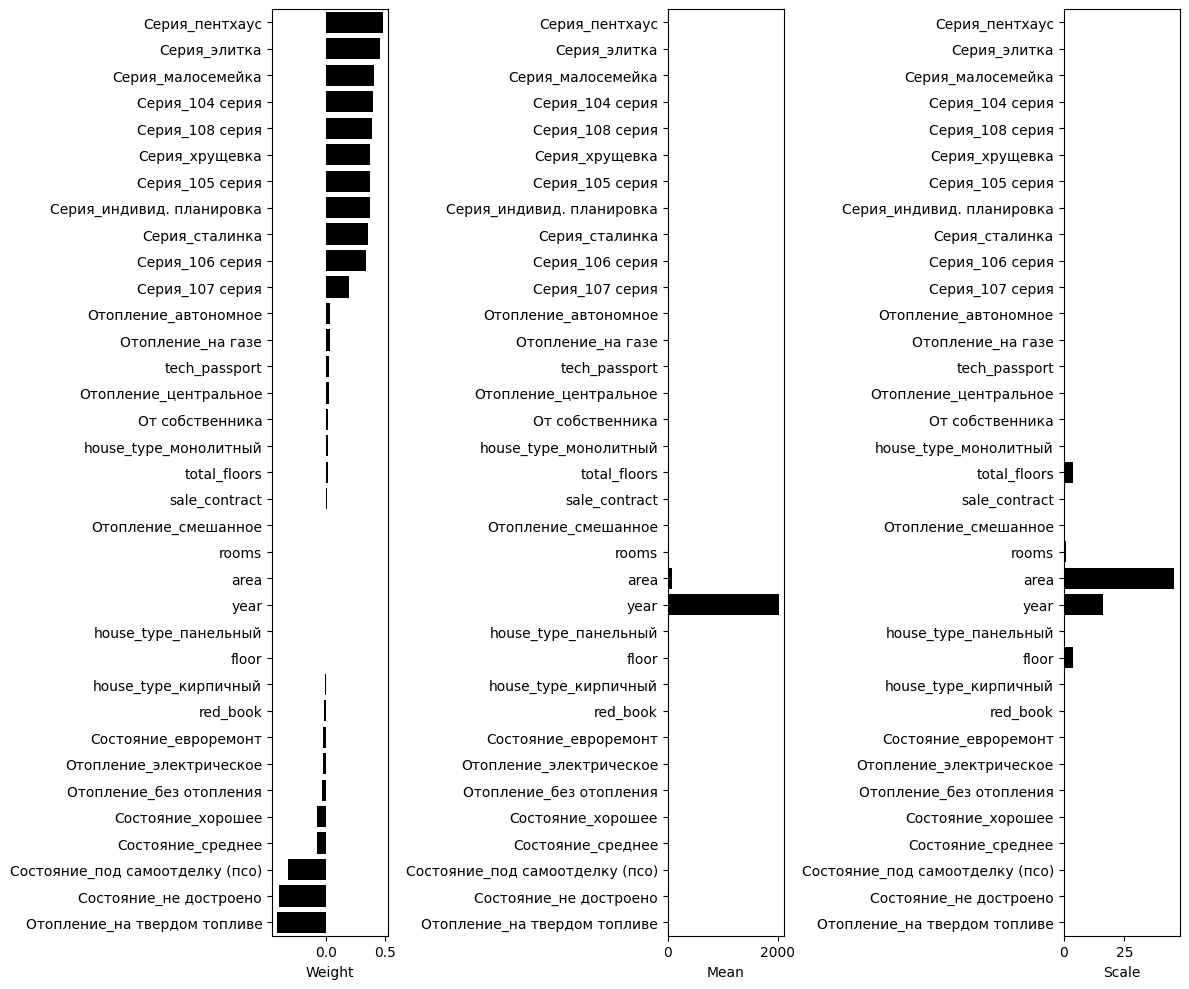

In [10]:
show_weights(X, model.coef_, X.mean(), X.std())

In [11]:
print("R2:\t %.4f" % r2_score(y_test, y_pred))
print("MAPE:\t %.4f" % mean_absolute_percentage_error(y_test, y_pred))
print('-----------------')
print("MSE:\t %.4f" % mean_squared_error(y_test, y_pred))
print("RMSE:\t %.4f" % np.sqrt(mean_squared_error(y_test, y_pred)))
print("MAE:\t %.4f" % mean_absolute_error(y_test, y_pred))

R2:	 0.0055
MAPE:	 0.1450
-----------------
MSE:	 7292969.9384
RMSE:	 2700.5499
MAE:	 279.9833


### Кросс валидация

In [12]:
cv_scores = cross_val_score(model, X, np.expm1(y), cv=5, scoring='neg_root_mean_squared_error')
print("Cross validation scores:\n\t", "\n\t".join("%.4f" % x for x in cv_scores))
print("Mean CV RMSE = %.4f" % np.mean(-cv_scores))

Cross validation scores:
	 -312.6911
	-2701.9510
	-314.1526
	-319.1864
	-452.2699
Mean CV RMSE = 820.0502


In [13]:
cv_scores = cross_val_score(model, X, np.expm1(y), cv=5, scoring='neg_mean_absolute_error')
print("Cross validation scores:\n\t", "\n\t".join("%.4f" % x for x in cv_scores))
print("Mean CV MAE = %.4f" % np.mean(-cv_scores))

Cross validation scores:
	 -238.0550
	-290.2183
	-239.4162
	-241.7890
	-242.5497
Mean CV MAE = 250.4056


In [14]:
cv_scores = cross_val_score(model, X, np.expm1(y), cv=5, scoring='r2')
print("Cross validation scores:\n\t", "\n\t".join("%.4f" % x for x in cv_scores))
print("Mean CV R2 = %.4f" % np.mean(-cv_scores))

Cross validation scores:
	 0.1483
	0.0055
	0.1007
	0.1455
	0.0972
Mean CV R2 = -0.0995


In [15]:
cv_scores = cross_val_score(model, X, np.expm1(y), cv=5, scoring='neg_mean_absolute_percentage_error')
print("Cross validation scores:\n\t", "\n\t".join("%.4f" % x for x in cv_scores))
print("Mean CV MAPE = %.4f" % np.mean(-cv_scores))

Cross validation scores:
	 -0.1686
	-0.1521
	-0.1723
	-0.1726
	-0.1699
Mean CV MAPE = 0.1671


## Проверка модели на submission.csv

In [16]:
y_sub_pred_log = model.predict(X_sub)
y_sub_pred = np.expm1(y_sub_pred_log)
y_sub = y_sub_pred * X_sub['area']
submission_data = pd.DataFrame({'id': test_ids, 'usd_price': y_sub})
submission_data.to_csv('data\LinearRegression.csv', index=False)